In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions

/home/white/anaconda3/envs/nexusdemand/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [2]:
data = pd.read_csv("../data/processed/demand_timeseries.csv")
data.head()

,Unnamed: 0,Date,StockCode,Quantity
0,0,2009-12-01,15036,55.0
1,1,2009-12-02,15036,0.0
2,2,2009-12-03,15036,240.0
3,3,2009-12-04,15036,12.0
4,4,2009-12-05,15036,12.0


In [3]:
data = data.drop(columns = ["Unnamed: 0"], errors = "ignore")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18700 entries, 0 to 18699
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       18700 non-null  object 
 1   StockCode  18700 non-null  object 
 2   Quantity   18700 non-null  float64
dtypes: float64(1), object(2)
memory usage: 438.4+ KB


In [4]:
data["Date"] = pd.to_datetime(data["Date"])
data["StockCode"] = data["StockCode"].astype(str)
data = data.sort_values(["StockCode", "Date"])
data.head()

,Date,StockCode,Quantity
0,2009-12-01,15036,55.0
1,2009-12-02,15036,0.0
2,2009-12-03,15036,240.0
3,2009-12-04,15036,12.0
4,2009-12-05,15036,12.0


##### Define forecasting settings

In [5]:
freq = "D"

context_length = 30       # model looks at last 30 days
prediction_length = 7     # model predicts next 7 days

cutoff_date = data["Date"].max() - pd.Timedelta(days=prediction_length)

print("Last date in data:", data["Date"].max())
print("Training ends on:", cutoff_date)
print("Forecast horizon starts on:", cutoff_date + pd.Timedelta(days=1))

Last date in data: 2010-12-09 00:00:00
Training ends on: 2010-12-02 00:00:00
Forecast horizon starts on: 2010-12-03 00:00:00


##### Add time features

We want to use cyclic features instead plain numbers. We want to do this because Sunday and Monday are close in reality but if we use plain numbers it would classify the model that it was far from each other.

In [6]:
data["day_of_week"] = data["Date"].dt.dayofweek
data["month"] = data["Date"].dt.month

data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)

data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)

feature_cols = [
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_weekend"
]

data.head()

,Date,StockCode,Quantity,day_of_week,month,dow_sin,dow_cos,month_sin,month_cos,is_weekend
0,2009-12-01,15036,55.0,1,12,0.781831,0.623490,-2.449294e-16,1.0,0
1,2009-12-02,15036,0.0,2,12,0.974928,-0.222521,-2.449294e-16,1.0,0
2,2009-12-03,15036,240.0,3,12,0.433884,-0.900969,-2.449294e-16,1.0,0
3,2009-12-04,15036,12.0,4,12,-0.433884,-0.900969,-2.449294e-16,1.0,0
4,2009-12-05,15036,12.0,5,12,-0.974928,-0.222521,-2.449294e-16,1.0,1


##### Scale each product separately

In [7]:
scalers = {}
data["scaled_sales"] = np.nan

for stock_code, group in data.groupby("StockCode"):
    train_mask = group["Date"] <= cutoff_date

    scaler = StandardScaler()
    scaler.fit(group.loc[train_mask, ["Quantity"]])

    scaled_values = scaler.transform(group[["Quantity"]]).flatten()

    data.loc[group.index, "scaled_sales"] = scaled_values
    scalers[stock_code] = scaler

data.head()

,Date,StockCode,Quantity,day_of_week,month,dow_sin,dow_cos,month_sin,month_cos,is_weekend,scaled_sales
0,2009-12-01,15036,55.0,1,12,0.781831,0.623490,-2.449294e-16,1.0,0,0.355779
1,2009-12-02,15036,0.0,2,12,0.974928,-0.222521,-2.449294e-16,1.0,0,-0.513723
2,2009-12-03,15036,240.0,3,12,0.433884,-0.900969,-2.449294e-16,1.0,0,3.280467
3,2009-12-04,15036,12.0,4,12,-0.433884,-0.900969,-2.449294e-16,1.0,0,-0.324014
4,2009-12-05,15036,12.0,5,12,-0.974928,-0.222521,-2.449294e-16,1.0,1,-0.324014


##### Train Test Split

In [8]:
train_data = data[data["Date"] <= cutoff_date].copy()
test_data = data.copy()

print("Train date range:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTest date range:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Train date range:
2009-12-01 00:00:00 to 2010-12-02 00:00:00

Test date range:
2009-12-01 00:00:00 to 2010-12-09 00:00:00


##### Remove products with too little history

This to ensure that every product would have the same history and none is smaller or bigger than each other 

In [9]:
min_required_length = context_length + prediction_length

valid_products = (
    train_data.groupby("StockCode")
    .size()
    .loc[lambda x: x >= min_required_length]
    .index
)

train_data = train_data[train_data["StockCode"].isin(valid_products)].copy()
test_data = test_data[test_data["StockCode"].isin(valid_products)].copy()

print("Number of valid products:", len(valid_products))

Number of valid products: 50


##### Create GluonTS dataset

GluonTS libraries was used because it can handles the sliding window internally

In [10]:
def create_gluonts_dataset(df):
    dataset_list = []

    for stock_code, group in df.groupby("StockCode"):
        group = group.sort_values("Date")

        target_values = group["scaled_sales"].values.astype(np.float32)

        dynamic_features = group[feature_cols].values.T.astype(np.float32)

        dataset_list.append({
            "start": pd.Period(group["Date"].iloc[0], freq=freq),
            "target": target_values,
            "feat_dynamic_real": dynamic_features,
            "item_id": stock_code
        })

    return ListDataset(dataset_list, freq=freq)


train_ds = create_gluonts_dataset(train_data)
test_ds = create_gluonts_dataset(test_data)

##### Train DeepAR

In [11]:
estimator = DeepAREstimator(
    freq=freq,
    prediction_length=prediction_length,
    context_length=context_length,

    num_layers=2,
    hidden_size=40,
    batch_size=32,

    num_feat_dynamic_real=len(feature_cols),

    # We already scaled each product manually
    scaling=False,

    trainer_kwargs={
        "max_epochs": 20,
        "accelerator": "auto",
        "enable_progress_bar": True
    }
)

predictor = estimator.train(training_data=train_ds)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/white/anaconda3/envs/nexusdemand/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/white/anaconda3/envs/nexusdemand/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should

Epoch 0: |          | 50/? [00:02<00:00, 23.12it/s, v_num=0, train_loss=1.170]

Epoch 0, global step 50: 'train_loss' reached 1.17145 (best 1.17145), saving model to '/home/white/projects_sg/NexusDemand/notebooks/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1


Epoch 1: |          | 50/? [00:01<00:00, 29.13it/s, v_num=0, train_loss=1.020]

Epoch 1, global step 100: 'train_loss' reached 1.02330 (best 1.02330), saving model to '/home/white/projects_sg/NexusDemand/notebooks/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1


...

Epoch 18: |          | 50/? [00:01<00:00, 28.88it/s, v_num=0, train_loss=0.480]

Epoch 18, global step 950: 'train_loss' was not in top 1


Epoch 19: |          | 50/? [00:01<00:00, 28.18it/s, v_num=0, train_loss=0.495]

Epoch 19, global step 1000: 'train_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: |          | 50/? [00:01<00:00, 28.01it/s, v_num=0, train_loss=0.495]


##### Generate probabilistic forecasts

In [12]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100
)

forecasts = list(forecast_it)
tss = list(ts_it)

print("Number of forecasts:", len(forecasts))
print("Example item:", forecasts[0].item_id)

Number of forecasts: 50
Example item: 15036


In [13]:
def quantile_loss(y_true, y_pred, q):
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))


def inverse_scale(stock_code, values):
    scaler = scalers[stock_code]
    return scaler.inverse_transform(values.reshape(-1, 1)).flatten()

##### Evaluate p10, p50, p90, and coverage

In [14]:
evaluation_rows = []

for forecast in forecasts:
    stock_code = str(forecast.item_id)

    product_actuals = (
        test_data[test_data["StockCode"] == stock_code]
        .sort_values("Date")
        .tail(prediction_length)
    )

    y_true = product_actuals["Quantity"].values

    p10_scaled = forecast.quantile(0.1)
    p50_scaled = forecast.quantile(0.5)
    p90_scaled = forecast.quantile(0.9)

    p10 = inverse_scale(stock_code, p10_scaled)
    p50 = inverse_scale(stock_code, p50_scaled)
    p90 = inverse_scale(stock_code, p90_scaled)

    mae_p50 = np.mean(np.abs(y_true - p50))

    ql_p10 = quantile_loss(y_true, p10, 0.1)
    ql_p50 = quantile_loss(y_true, p50, 0.5)
    ql_p90 = quantile_loss(y_true, p90, 0.9)

    coverage_80 = np.mean((y_true >= p10) & (y_true <= p90))

    evaluation_rows.append({
        "StockCode": stock_code,
        "MAE_p50": mae_p50,
        "QL_p10": ql_p10,
        "QL_p50": ql_p50,
        "QL_p90": ql_p90,
        "Coverage_80": coverage_80
    })

eval_df = pd.DataFrame(evaluation_rows)

eval_df.head()

,StockCode,MAE_p50,QL_p10,QL_p50,QL_p90,Coverage_80
0,15036,6.382737,2.907094,3.191368,3.189778,1.000000
1,16014,3.564262,0.378224,1.782131,3.085723,0.285714
2,17003,135.563487,16.719255,67.781743,110.822820,0.714286
3,20724,10.730517,3.071020,5.365258,3.714823,1.000000
4,20725,27.714241,5.777738,13.857121,4.914271,0.714286


In [15]:
print("Average MAE p50:", eval_df["MAE_p50"].mean())
print("Average Quantile Loss p10:", eval_df["QL_p10"].mean())
print("Average Quantile Loss p50:", eval_df["QL_p50"].mean())
print("Average Quantile Loss p90:", eval_df["QL_p90"].mean())
print("Average 80% Coverage:", eval_df["Coverage_80"].mean())

Average MAE p50: 27.950357537297258
Average Quantile Loss p10: 5.8013289899993765
Average Quantile Loss p50: 13.975178768648629
Average Quantile Loss p90: 10.883021688458534
Average 80% Coverage: 0.8057142857142856


With above data we can interpretate that

with Coverage_80 much lower than 0.80 we can conclude that model is overconfident. While the point predictions are tracking the general trend, the model is consistently underestimating the range of potential outcomes. So model's only captures 71% of actual events so the model only play on the 'safe zone'

In [16]:
target_id = "21212"
forecast = next((f for f in forecasts if f.item_id == target_id), None)
stock_code = str(forecast.item_id)

product_actuals = (
    test_data[test_data["StockCode"] == stock_code]
    .sort_values("Date")
    .tail(prediction_length)
)

forecast_dates = product_actuals["Date"].values
y_true = product_actuals["Quantity"].values

p10 = inverse_scale(stock_code, forecast.quantile(0.1))
p50 = inverse_scale(stock_code, forecast.quantile(0.5))
p90 = inverse_scale(stock_code, forecast.quantile(0.9))

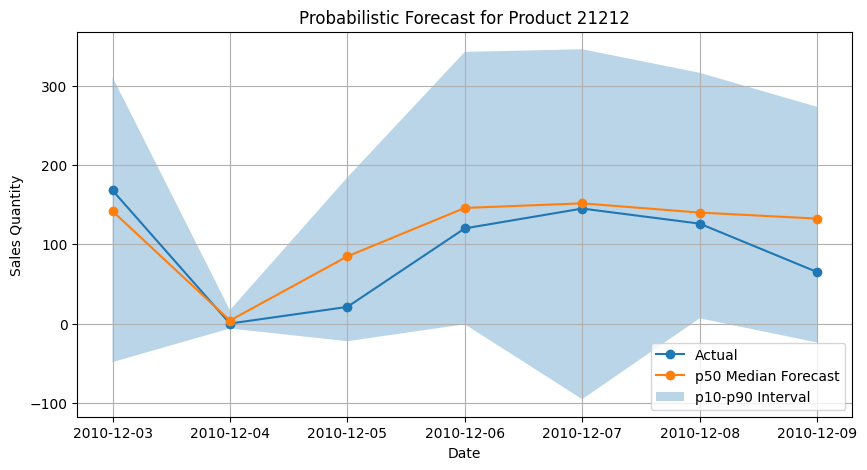

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(forecast_dates, y_true, marker="o", label="Actual")
plt.plot(forecast_dates, p50, marker="o", label="p50 Median Forecast")

plt.fill_between(
    forecast_dates,
    p10,
    p90,
    alpha=0.3,
    label="p10-p90 Interval"
)

plt.title(f"Probabilistic Forecast for Product {stock_code}")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def eval_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {model_name} ---")
    print(f"MAE (Avg error in units): {mae:.2f}")
    print(f"RMSE (Penalty for big misses): {rmse:.2f}\n")

eval_model(y_true, p50, "DeepAR Model")

--- DeepAR Model ---
MAE (Avg error in units): 29.63
RMSE (Penalty for big misses): 38.17



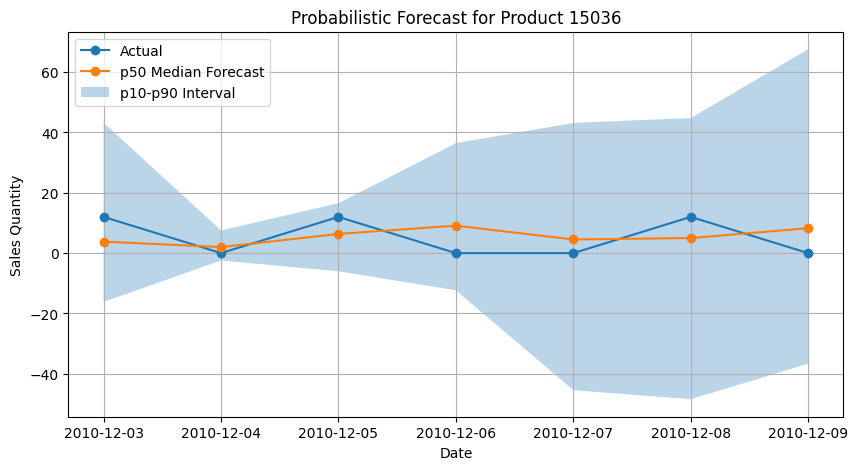

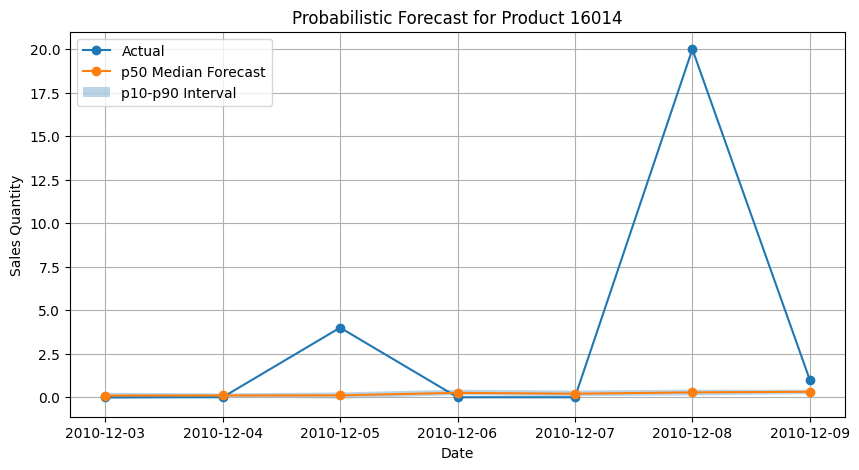

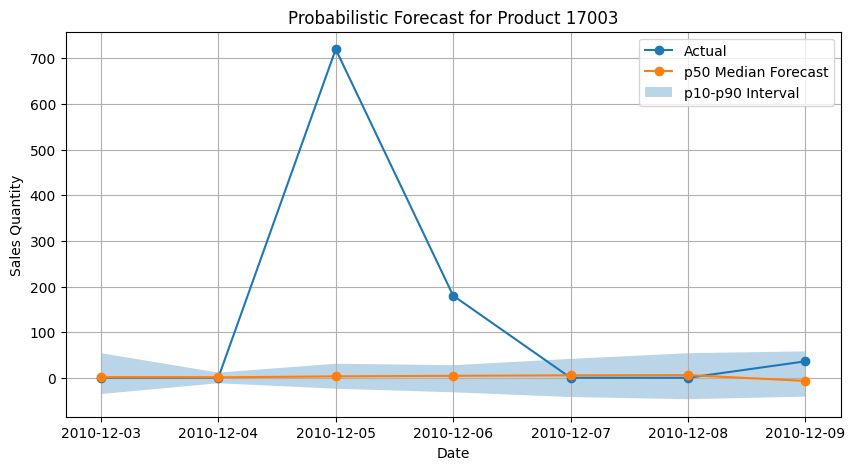

In [19]:
for i in range(min(3, len(forecasts))):
    forecast = forecasts[i]
    stock_code = str(forecast.item_id)

    product_actuals = (
        test_data[test_data["StockCode"] == stock_code]
        .sort_values("Date")
        .tail(prediction_length)
    )

    forecast_dates = product_actuals["Date"].values
    y_true = product_actuals["Quantity"].values

    p10 = inverse_scale(stock_code, forecast.quantile(0.1))
    p50 = inverse_scale(stock_code, forecast.quantile(0.5))
    p90 = inverse_scale(stock_code, forecast.quantile(0.9))

    plt.figure(figsize=(10, 5))

    plt.plot(forecast_dates, y_true, marker="o", label="Actual")
    plt.plot(forecast_dates, p50, marker="o", label="p50 Median Forecast")

    plt.fill_between(
        forecast_dates,
        p10,
        p90,
        alpha=0.3,
        label="p10-p90 Interval"
    )

    plt.title(f"Probabilistic Forecast for Product {stock_code}")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
forecast_summary_rows = []

for forecast in forecasts:
    stock_code = str(forecast.item_id)

    p10 = inverse_scale(stock_code, forecast.quantile(0.1))
    p50 = inverse_scale(stock_code, forecast.quantile(0.5))
    p90 = inverse_scale(stock_code, forecast.quantile(0.9))

    forecast_summary_rows.append({
        "StockCode": stock_code,
        "ForecastHorizonDays": prediction_length,
        "DemandP10": max(0, p10.sum()),
        "DemandP50": max(0, p50.sum()),
        "DemandP90": max(0, p90.sum())
    })

forecast_summary = pd.DataFrame(forecast_summary_rows)
forecast_summary.head()

,StockCode,ForecastHorizonDays,DemandP10,DemandP50,DemandP90
0,15036,7,0.000000,39.031284,259.284485
1,16014,7,0.270505,1.360883,2.452777
2,17003,7,0.000000,13.987839,276.808228
3,20724,7,0.000000,129.815948,378.037628
4,20725,7,0.000000,209.604828,549.372803


In [21]:
forecast_summary.to_csv(
    "../data/processed/forecast_summary_7d.csv",
    index=False
)

In [22]:
from pathlib import Path
from gluonts.model.predictor import Predictor

save_path = Path("../data/processed/DeepAR/")
predictor.serialize(save_path)

In [23]:
import pickle

with open("../data/processed/scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)